## MCA Major Project

** Developed By:** Athira Nair

---

## Objective

The objective of this project is to classify SMS messages as Spam or Ham using Machine Learning algorithms. The project compares multiple algorithms and selects the best-performing model based on evaluation metrics.

In [3]:
import os
import sys

#To get thw project root directory
project_root = os.path.abspath("..")

#Add it to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added: ", project_root)

Project root added:  d:\Spam Detection


In [4]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 

from wordcloud import WordCloud 

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from src.preprocess import clean_text
from src.feature_extraction import create_vectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Athira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

#To keep only the required columns
df = df[['v1', 'v2']]

#Rename columns
df.columns = ["label", "message"]

#Display the first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print("Dataset Information")
print("-" * 40)

df.info()

Dataset Information
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [7]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows : 5572
Number of Columns : 2


In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

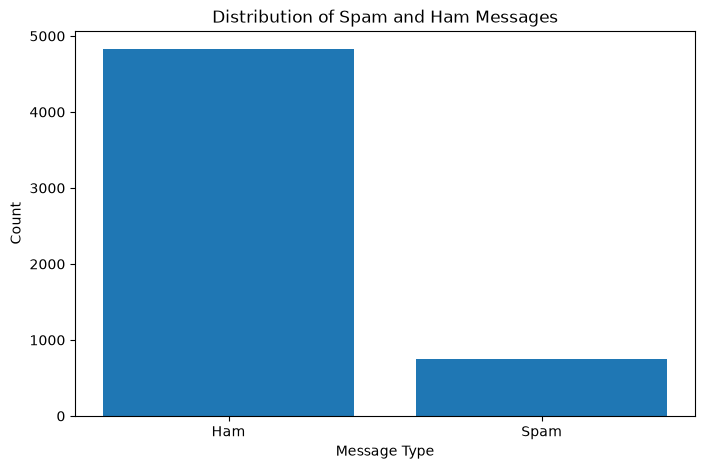

In [15]:
counts = df["label"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(["Ham", "Spam"], [counts["ham"], counts["spam"]])

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

#Save the figure
plt.savefig(r"D:\Spam Detection\report_images\fig4_1_class_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [10]:
df["length"] = df["message"].apply(len)

df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [11]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [12]:
spam_messages = " ".join(
    df[df["label"] == "spam"]["message"]
)

ham_messages = " ".join(
    df[df["label"] == "ham"]["message"]
)

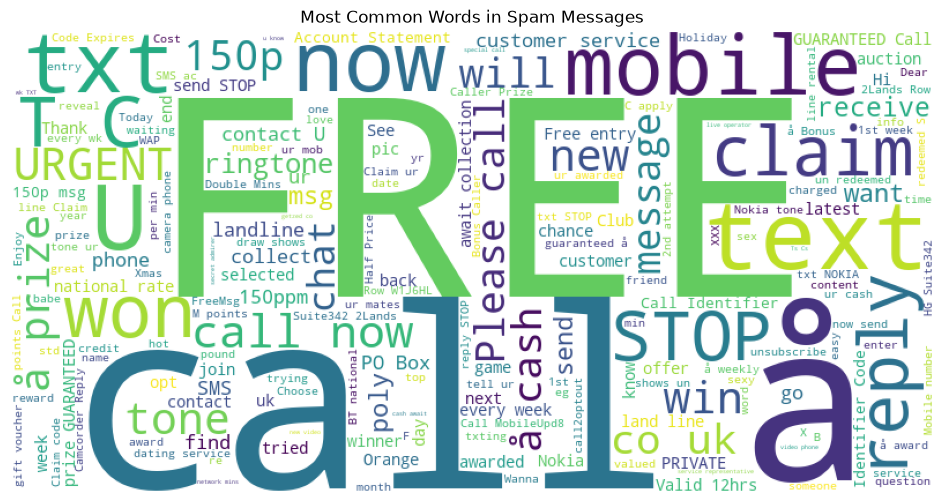

In [13]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_messages)

plt.figure(figsize=(12,6))
plt.imshow(spam_wordcloud)

plt.axis("off")

plt.title("Most Common Words in Spam Messages")

plt.show()

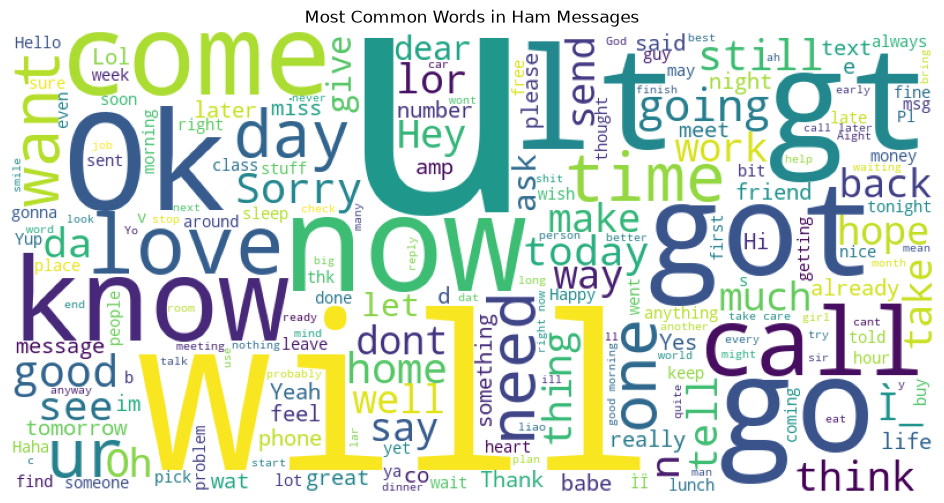

In [14]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_messages)

plt.figure(figsize=(12,6))
plt.imshow(ham_wordcloud)

plt.axis("off")

plt.title("Most Common Words in Ham Messages")

plt.show()

In [15]:
df["clean_message"] = df["message"].apply(clean_text)

df[
    ["message", "clean_message"]
].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazi avail bugi great world buff...
1,Ok lar... Joking wif u oni...,lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win cup final tkt may tex...
3,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [16]:
df["label"] = df["label"].map(
    {
        "ham": 0,
        "spam": 1
    }
)

In [17]:
vectorizer = create_vectorizer()

X = vectorizer.fit_transform(
    df["clean_message"]
)

y = df["label"]

print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(5572, 10000)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 4457
Testing Samples : 1115


In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [20]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [21]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [22]:
svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Support Vector Machine trained successfully.")

d:\Spam Detection\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Machine trained successfully.


In [23]:
from src.evaluate_model import evaluate_model

In [24]:
nb_results = evaluate_model(nb_model, X_test, y_test)

nb_results

{'accuracy': 0.9641255605381166,
 'precision': 0.9824561403508771,
 'recall': 0.7466666666666667,
 'f1_score': 0.8484848484848485,
 'confusion_matrix': array([[963,   2],
        [ 38, 112]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.96      1.00      0.98       965\n           1       0.98      0.75      0.85       150\n\n    accuracy                           0.96      1115\n   macro avg       0.97      0.87      0.91      1115\nweighted avg       0.96      0.96      0.96      1115\n'}

In [25]:
lr_results = evaluate_model(lr_model, X_test, y_test)

lr_results

{'accuracy': 0.9381165919282511,
 'precision': 0.9655172413793104,
 'recall': 0.56,
 'f1_score': 0.7088607594936709,
 'confusion_matrix': array([[962,   3],
        [ 66,  84]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.94      1.00      0.97       965\n           1       0.97      0.56      0.71       150\n\n    accuracy                           0.94      1115\n   macro avg       0.95      0.78      0.84      1115\nweighted avg       0.94      0.94      0.93      1115\n'}

In [26]:
svm_results = evaluate_model(svm_model, X_test, y_test)

svm_results

{'accuracy': 0.9739910313901345,
 'precision': 0.9548872180451128,
 'recall': 0.8466666666666667,
 'f1_score': 0.8975265017667845,
 'confusion_matrix': array([[959,   6],
        [ 23, 127]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.99      0.99       965\n           1       0.95      0.85      0.90       150\n\n    accuracy                           0.97      1115\n   macro avg       0.97      0.92      0.94      1115\nweighted avg       0.97      0.97      0.97      1115\n'}

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Accuracy": [
        nb_results["accuracy"],
        lr_results["accuracy"],
        svm_results["accuracy"] 
    ],
    "Precision": [
        nb_results["precision"],
        lr_results["precision"],
        svm_results["precision"]
    ],
    "Recall": [
        nb_results["recall"],
        lr_results["recall"],
        svm_results["recall"]
    ],
    "F1 Score": [
        nb_results["f1_score"],
        lr_results["f1_score"],
        svm_results["f1_score"]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.964126,0.982456,0.746667,0.848485
1,Logistic Regression,0.938117,0.965517,0.560000,0.708861
2,Support Vector Machine,0.973991,0.954887,0.846667,0.897527


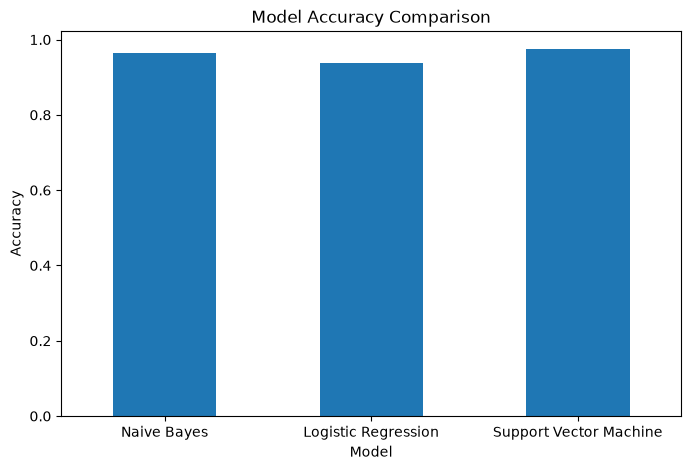

In [28]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.show()

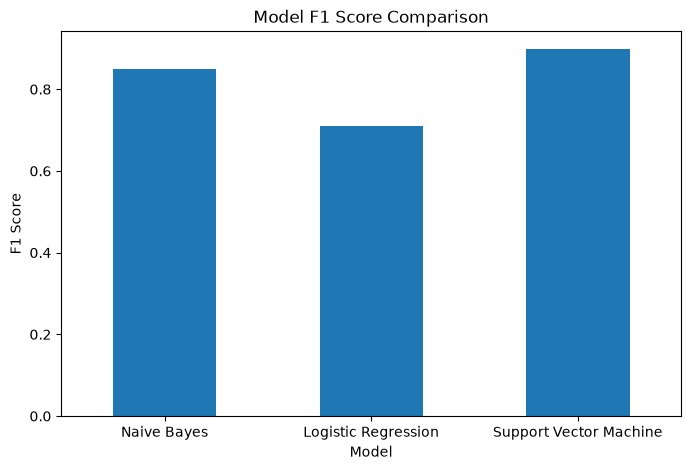

In [29]:
comparison.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")

plt.xticks(rotation=0)

plt.show()

In [30]:
best_model = comparison.loc[comparison["F1 Score"].idxmax()]

best_model

Model        Support Vector Machine
Accuracy                   0.973991
Precision                  0.954887
Recall                     0.846667
F1 Score                   0.897527
Name: 2, dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

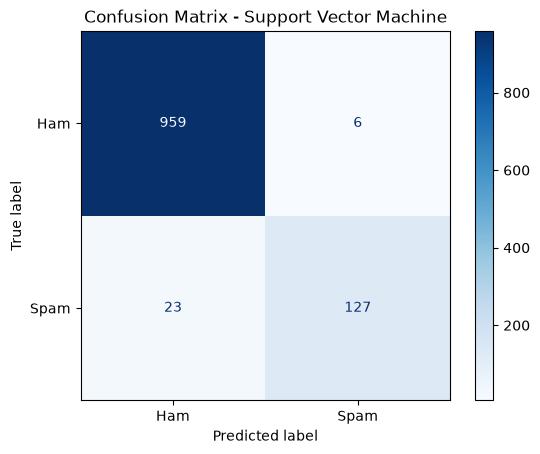

In [31]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Support Vector Machine")
plt.show

In [32]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# Conclusion

Three machine learning algorithms were trained and evaluated for SMS spam detection.

- Multinomial Naive Bayes
- Logistic Regression
- Support Vector Machine

Among these, the Support Vector Machine achieved the highest F1 Score and was selected as the final model.

The trained model was integrated into a Streamlit web application capable of classifying SMS messages in real time.
